# 0_13 — Proteases of the experimental control panel

## Scope

The source audits `0_01` to `0_03` select proteases by data availability. This
notebook introduces the independent criterion: which proteases the experimental
control panel of the project actually names, and whether the local MEROPS
datasets and the window-resolved sources cover them.

The control panel is `configs/clasp-controls.tsv`, a curated table of
antimicrobial peptides with their reported proteolytic fate, the protease
responsible, and where available the cleaved bonds. It is the set against which
a cleavage model is checked.

Data availability and experimental relevance are separate axes. Combining them
into one verdict, as an earlier version of the decision table did, selects
proteases by the criterion that is easier to satisfy.

## Questions

1. Which proteases does the control panel name, and with what evidence?
2. Where does each of them have a MEROPS specificity matrix: the serum panel,
   the full human set, a pathogen set, or nowhere?
3. How do those matrices compare, on the diagnostics of `0_01`, with the
   matrices of the proteases the source audits selected?
4. How many control rows report explicit bonds, and are therefore usable as a
   site-level test?

## Execution contract

**Inputs:** `assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/configs/clasp-controls.tsv`; `data/merops/index.json`; `data/merops/*/codes.json`; `results/0_01_merops_matrices.csv`; `results/0_05_mmp_pics_coverage.csv`; `results/0_06_dpp4_qpisa_coverage.csv`; `data/peptides_data/peptides_mic/peptides_apex.csv`.

**Outputs:** `results/0_13_control_panel_labels.csv`.

**Depends on:** `0_01`, `0_05`, `0_06`.

**Boundary:** Named controls and matrix coverage do not establish serum half-life or MIC outcomes.

In [1]:
import csv
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    ProteasePanel,
    bootstrap_specificity_matrices,
    information_content_excess,
    load_amino_acid_background,
    load_protease_panel,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
CONTROLS_TSV = common.ANALYSIS_ROOT / "configs" / "clasp-controls.tsv"
HUMAN_COMPOSITION = common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
SERUM_DATASET_ID = common.SERUM_DATASET_ID
HUMAN_DATASET_ID = 34

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_PROBE_PEPTIDES = 1000
N_BOOTSTRAP = 32
SEED = 20260920

In [3]:
human_background = load_amino_acid_background(HUMAN_COMPOSITION)

print(f"device: {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")
print(f"control panel: {common.describe_source(CONTROLS_TSV)}")

device: cuda
gpu: NVIDIA GeForce GTX 1060 6GB
control panel: {'path': 'assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/configs/clasp-controls.tsv', 'exists': True, 'bytes': 11603}


## Contents of the control panel

Each row is one (peptide, protease) observation with a reported outcome. The
`class` column records whether the peptide was degraded, resisted degradation,
or is a counterexample that a window model is not expected to explain.

In [4]:
controls = pd.read_csv(CONTROLS_TSV, sep="\t", dtype=str).fillna("")
controls["has_explicit_bonds"] = controls["cleavage_sites"].str.contains(r"\|", regex=True) & ~controls[
    "cleavage_sites"
].str.startswith("products")

print(f"rows: {len(controls)} | peptides: {controls['peptide_id'].nunique()} | "
      f"sequences: {controls['sequence'].nunique()}")
print()
print("outcome class:")
print(controls["class"].value_counts().to_string())
print()
print("origin of the protease:")
print(controls["panel"].value_counts().to_string())
print()
print(f"rows reporting explicit bonds: {int(controls['has_explicit_bonds'].sum())}")
print("evidence confidence:")
print(controls["confidence"].value_counts().to_string())

rows: 28 | peptides: 13 | sequences: 13

outcome class:
class
labile            22
stable             5
counterexample     1

origin of the protease:
panel
eskape_saureus        12
eskape_paeruginosa     3
serum_host             3
mixed                  3
other_ecoli            2
host_inflammatory      2
eskape_efaecalis       1
other_pmirabilis       1
skin_host              1

rows reporting explicit bonds: 13
evidence confidence:
confidence
high        16
medium       7
inferred     4
low          1


## MEROPS coverage of the named proteases

A protease is scoreable only where MEROPS holds a specificity matrix for its
code. The local datasets are the 34 pathogen sets (ids 0 to 33), the full human
set (id 34) and the human serum subset (id 35), which is the panel the source
audits examined.

In [5]:
merops_index = json.loads((common.MEROPS_ROOT / "index.json").read_text())
dataset_labels = {int(key): entry["label"] for key, entry in merops_index["by_index"].items()}

## Locate every code of every dataset once
code_locations: dict[str, dict[int, int]] = {}
for key, entry in merops_index["by_index"].items():
    metadata = json.loads((common.MEROPS_ROOT / entry["folder"] / "codes.json").read_text())
    for peptidase in metadata["peptidases"]:
        code_locations.setdefault(peptidase["code"], {})[int(key)] = int(peptidase["n_cleavages"])

## Expand the semicolon-separated codes of the control table
named: dict[str, set[str]] = {}
for _, row in controls.iterrows():
    for code in row["merops_id"].split(";"):
        code = code.strip()
        if code and code not in {"na", "mixed"}:
            named.setdefault(code, set()).add(row["protease"])

coverage_rows = []
for code in sorted(named):
    locations = code_locations.get(code, {})
    best_dataset = max(locations, key=lambda key: locations[key]) if locations else None
    coverage_rows.append(
        {
            "merops_code": code,
            "control_protease": "/".join(sorted(named[code])),
            "in_serum_panel": SERUM_DATASET_ID in locations,
            "in_human_set": HUMAN_DATASET_ID in locations,
            "n_datasets": len(locations),
            "best_dataset_id": best_dataset,
            "best_dataset_label": dataset_labels.get(best_dataset, "") if best_dataset is not None else "",
            "n_cleavages": locations.get(best_dataset, 0) if best_dataset is not None else 0,
        }
    )
coverage = pd.DataFrame(coverage_rows)

print(coverage.to_string(index=False))
print()
print(f"named codes with no MEROPS matrix anywhere: "
      f"{int((coverage['n_cleavages'] == 0).sum())}")
print(f"named codes present in the audited serum panel: {int(coverage['in_serum_panel'].sum())}")
print(f"named codes that are human but outside the serum panel: "
      f"{int((coverage['in_human_set'] & ~coverage['in_serum_panel']).sum())}")
print(f"named codes from pathogen datasets: "
      f"{int((~coverage['in_human_set'] & (coverage['n_cleavages'] > 0)).sum())}")

merops_code    control_protease  in_serum_panel  in_human_set  n_datasets  best_dataset_id                           best_dataset_label  n_cleavages
    A26.001 OmpT_EHEC/OmpT_EPEC           False         False           4              1.0                           E. coli ATCC 11775           54
    M04.005    LasB_pseudolysin           False         False           2              5.0                           P. aeruginosa PA01           70
    M04.007     GelE_coccolysin           False         False           2              9.0 vancomycin-resistant E. faecalis ATCC 700802           25
    M04.009          aureolysin           False         False           2              7.0                         S. aureus ATCC 12600           24
    M10.057                ZapA           False         False           0              NaN                                                         0
    S01.017           KLK5_KLK7           False          True           1             34.0                

## Matrix quality of the control proteases

The diagnostics of `0_01` are recomputed for the control codes on the dataset
that holds the most evidence for each of them, so that their matrices can be
compared with those of the serum panel on one scale.

In [6]:
probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
    .sample(n=N_PROBE_PEPTIDES, random_state=SEED)
    .reset_index(drop=True)
)
probe_sequences = probe["sequence"].tolist()

scoreable = coverage[coverage["n_cleavages"] > 0]
diagnostics = []
for dataset_id in sorted(scoreable["best_dataset_id"].unique()):
    codes_here = scoreable.query("best_dataset_id == @dataset_id")["merops_code"].tolist()

    counts_panel = load_protease_panel(
        int(dataset_id), merops_root=common.MEROPS_ROOT, kind="counts", device="cpu"
    )
    logprob_panel = load_protease_panel(
        int(dataset_id), merops_root=common.MEROPS_ROOT, kind="logprob", device=DEVICE
    )
    counts = counts_panel.matrices.numpy().astype(np.float64)  # (N, P, A)
    rows_wanted = [counts_panel.codes.index(code) for code in codes_here]

    _, _, excess = information_content_excess(
        counts, n_samples=400, seed=SEED, background=human_background
    )  # (N, P)

    ## Rank reproducibility of each matrix under resampling of its own counts
    reference_rates, _ = CleavagePotential(
        logprob_panel, variant="product", device=DEVICE
    ).sequence_protease_rates(probe_sequences)  # (n_probe, N)
    replicates = bootstrap_specificity_matrices(counts, n_replicates=N_BOOTSTRAP, seed=SEED)
    stability = np.zeros((N_BOOTSTRAP, len(rows_wanted)))
    for replicate in range(N_BOOTSTRAP):
        replicate_rates, _ = CleavagePotential(
            ProteasePanel(
                matrices=torch.as_tensor(replicates[replicate], dtype=torch.float32, device=DEVICE),
                weights=logprob_panel.weights,
                codes=logprob_panel.codes,
            ),
            variant="product",
            device=DEVICE,
        ).sequence_protease_rates(probe_sequences)
        for position, row in enumerate(rows_wanted):
            correlation = spearmanr(reference_rates[:, row], replicate_rates[:, row]).statistic
            stability[replicate, position] = 0.0 if np.isnan(correlation) else correlation

    for position, (code, row) in enumerate(zip(codes_here, rows_wanted)):
        diagnostics.append(
            {
                "merops_code": code,
                "mean_divergence_excess": float(excess[row].mean()),
                "median_rank_stability": float(np.median(stability[:, position])),
            }
        )

diagnostics = pd.DataFrame(diagnostics)
coverage = coverage.merge(diagnostics, on="merops_code", how="left")
print(coverage[
    ["merops_code", "control_protease", "best_dataset_label", "n_cleavages",
     "mean_divergence_excess", "median_rank_stability"]
].sort_values("n_cleavages", ascending=False).round(3).to_string(index=False))

merops_code    control_protease                           best_dataset_label  n_cleavages  mean_divergence_excess  median_rank_stability
    S01.269             V8_SspA                         S. aureus ATCC 12600         4330                   0.479                  0.998
    S01.131        HNE_elastase                                 Homo sapiens          487                   0.307                  0.987
    S01.017           KLK5_KLK7                                 Homo sapiens           75                   0.362                  0.842
    M04.005    LasB_pseudolysin                           P. aeruginosa PA01           70                   0.297                  0.890
    A26.001 OmpT_EHEC/OmpT_EPEC                           E. coli ATCC 11775           54                   0.653                  0.869
    S01.300           KLK5_KLK7                                 Homo sapiens           43                   0.256                  0.725
    M04.007     GelE_coccolysin vancomyci

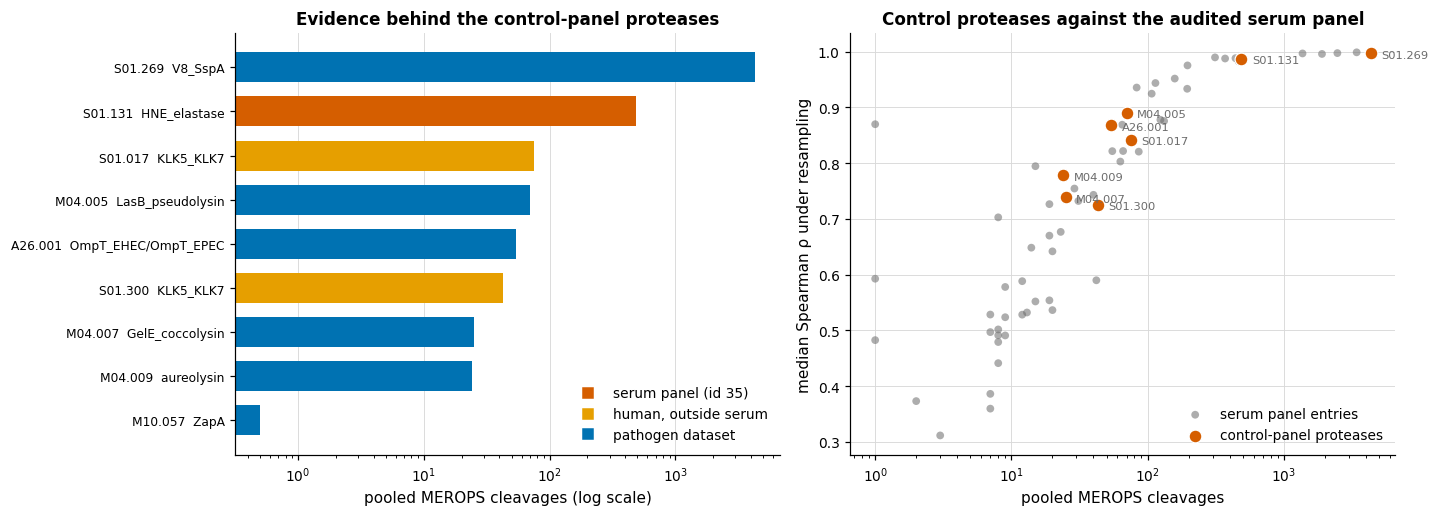

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

ax = axes[0]
ordered = coverage.sort_values("n_cleavages")
origin_color = []
for _, row in ordered.iterrows():
    if row["in_serum_panel"]:
        origin_color.append(common.CATEGORICAL_COLORS[1])
    elif row["in_human_set"]:
        origin_color.append(common.CATEGORICAL_COLORS[3])
    else:
        origin_color.append(common.CATEGORICAL_COLORS[0])
ax.barh(range(len(ordered)), ordered["n_cleavages"].clip(lower=0.5), color=origin_color, height=0.68)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(
    [f"{row.merops_code}  {row.control_protease[:22]}" for row in ordered.itertuples()], fontsize=8
)
ax.set_xscale("log")
ax.set_xlabel("pooled MEROPS cleavages (log scale)")
ax.set_title("Evidence behind the control-panel proteases")
ax.grid(axis="y", visible=False)
handles = [
    plt.Line2D([], [], marker="s", linestyle="", color=common.CATEGORICAL_COLORS[1], label="serum panel (id 35)"),
    plt.Line2D([], [], marker="s", linestyle="", color=common.CATEGORICAL_COLORS[3], label="human, outside serum"),
    plt.Line2D([], [], marker="s", linestyle="", color=common.CATEGORICAL_COLORS[0], label="pathogen dataset"),
]
ax.legend(handles=handles, loc="lower right")

ax = axes[1]
serum_audit = pd.read_csv(common.RESULTS_ROOT / "0_01_merops_matrices.csv")
ax.scatter(
    serum_audit["n_cleavages"],
    serum_audit["median_rank_stability"],
    s=26,
    color=common.NEUTRAL,
    alpha=0.55,
    edgecolor="none",
    label="serum panel entries",
)
scored = coverage.dropna(subset=["median_rank_stability"])
ax.scatter(
    scored["n_cleavages"],
    scored["median_rank_stability"],
    s=70,
    color=common.CATEGORICAL_COLORS[1],
    edgecolor="white",
    linewidth=0.8,
    label="control-panel proteases",
)
for _, row in scored.iterrows():
    ax.annotate(
        row["merops_code"],
        (row["n_cleavages"], row["median_rank_stability"]),
        textcoords="offset points",
        xytext=(7, -3),
        fontsize=7.5,
        color=common.NEUTRAL,
    )
ax.set_xscale("log")
ax.set_xlabel("pooled MEROPS cleavages")
ax.set_ylabel("median Spearman ρ under resampling")
ax.set_title("Control proteases against the audited serum panel")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Provenance**

The named control proteases and published bond annotations enter through `configs/clasp-controls.tsv`; code cell 5 parses those rows. MEROPS *Substrate_search* 2023 `data/merops/index.json` and each dataset's `codes.json` provide code presence and reported `n_cleavages`; code cells 8–10 choose a matrix and compute diagnostics, using the APEX table only as a scoring probe. One row of `results/0_13_control_panel_labels.csv` is a named MEROPS code, while `explicit_bonds` counts annotated cleavage bonds in the control TSV, not observed serum reactions. The joins to `results/0_05_mmp_pics_coverage.csv` and `0_06_dpp4_qpisa_coverage.csv` identify possible independent source coverage. Check `merops_id` and `cleavage_sites` in the TSV and `best_dataset_id` in the result. Publication-to-row traceability for every control bond is incomplete: TODO: provenance do ustalenia.

> **Caveat.** The code reads `results/0_05_mmp_pics_coverage.csv` and `0_06_dpp4_qpisa_coverage.csv`, but current notebooks `0_05` and `0_06` do not write these files. They are legacy saved artifacts and block a clean run from only current notebook outputs.


## Overlap with the sources that can replace a matrix

Only two sources provide window-resolved observations independent of MEROPS:
the MMP PICS libraries and the DPP4 qPISA dataset. The question here is whether
either covers a protease the control panel names.

In [8]:
pics = pd.read_csv(common.RESULTS_ROOT / "0_05_mmp_pics_coverage.csv")
qpisa = pd.read_csv(common.RESULTS_ROOT / "0_06_dpp4_qpisa_coverage.csv")

replaceable = set(pics["merops_code"].dropna()) | set(qpisa["merops_code"].dropna())
control_codes = set(coverage["merops_code"])

print(f"codes with an independent window-resolved dataset: {len(replaceable)}")
print(f"  {', '.join(sorted(replaceable))}")
print(f"codes named by the control panel: {len(control_codes)}")
print(f"  {', '.join(sorted(control_codes))}")
print()
print(f"intersection: {sorted(replaceable & control_codes) or 'empty'}")

coverage["independent_window_dataset"] = coverage["merops_code"].isin(replaceable)
coverage["named_in_control_panel"] = True

codes with an independent window-resolved dataset: 10
  M10.001, M10.002, M10.003, M10.004, M10.005, M10.008, M10.009, M10.013, M10.014, S09.003
codes named by the control panel: 9
  A26.001, M04.005, M04.007, M04.009, M10.057, S01.017, S01.131, S01.269, S01.300

intersection: empty


## Rows usable as a site-level test

A row constrains a window score only where the cleaved bond is reported. Rows
whose sites are unmapped, unassigned or inferred by homology constrain the
outcome of degradation but not the position of the cut.

In [9]:
controls["bond_count"] = controls["cleavage_sites"].apply(
    lambda value: len([part for part in value.split(";") if "|" in part])
)
usable = controls[controls["has_explicit_bonds"] & (controls["confidence"] == "high")]

print(f"rows with explicit bonds: {int(controls['has_explicit_bonds'].sum())} of {len(controls)}")
print(f"  of those marked high confidence: {len(usable)}")
print(f"  bonds reported in those rows: {int(usable['bond_count'].sum())}")
print(f"  distinct peptides: {usable['peptide_id'].nunique()} | "
      f"distinct proteases: {usable['protease'].nunique()}")
print()
print(
    usable[["peptide_id", "protease", "merops_id", "cleavage_sites", "class"]].to_string(index=False)
)

## Negative controls: rows reporting resistance under a named protease
resistant = controls[controls["class"].isin(["stable", "counterexample"])]
print()
print(f"rows reporting resistance: {len(resistant)} "
      f"({resistant['peptide_id'].nunique()} peptides)")

rows with explicit bonds: 13 of 28
  of those marked high confidence: 9
  bonds reported in those rows: 19
  distinct peptides: 5 | distinct proteases: 6

peptide_id         protease merops_id            cleavage_sites  class
     LL-37       aureolysin   M04.009   R19|I20;R23|I24;L31|V32 labile
     LL-37          V8_SspA   S01.269                   E16|F17 labile
     EFK17       aureolysin   M04.009             R4|I5;D11|F12 labile
     EFK17          V8_SspA   S01.269                     E1|F2 labile
     EFK17 LasB_pseudolysin   M04.005         E1|F2;R4|I5;R8|I9 labile
     EFK17     pooled_panel        na E1|F2;R4|I5;R8|I9;D11|F12 labile
      bCAT   sa_supernatant        na             L5|S6;G13|F14 labile
      hCAT   sa_supernatant        na             L5|S6;G13|F14 labile
     Onc18      mouse_serum        na                   R14|R15 labile

rows reporting resistance: 6 (4 peptides)


## Relevance table

One row per protease named by the control panel, with its MEROPS location,
matrix quality and whether an independent window-resolved dataset exists. The
table is the relevance axis of `0_14_dataset_definition.ipynb`.

In [10]:
site_rows = (
    controls[controls["has_explicit_bonds"]]
    .assign(code=lambda frame: frame["merops_id"].str.split(";"))
    .explode("code")
)
site_rows["code"] = site_rows["code"].str.strip()
bonds_per_code = site_rows.groupby("code")["bond_count"].sum()

coverage["explicit_bond_rows"] = coverage["merops_code"].map(
    site_rows.groupby("code").size()
).fillna(0).astype(int)
coverage["explicit_bonds"] = coverage["merops_code"].map(bonds_per_code).fillna(0).astype(int)
coverage["matrix_source"] = np.select(
    [
        coverage["in_serum_panel"],
        coverage["in_human_set"],
        coverage["n_cleavages"] > 0,
    ],
    ["merops_serum_panel", "merops_human_outside_serum", "merops_pathogen_dataset"],
    default="no_merops_matrix",
)

destination = common.save_result(coverage, "0_13_control_panel_labels.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
coverage[
    ["merops_code", "control_protease", "matrix_source", "n_cleavages",
     "median_rank_stability", "independent_window_dataset", "explicit_bonds"]
].sort_values("n_cleavages", ascending=False)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_13_control_panel_labels.csv


,merops_code,control_protease,matrix_source,n_cleavages,median_rank_stability,independent_window_dataset,explicit_bonds
7,S01.269,V8_SspA,merops_pathogen_dataset,4330,0.997536,False,2
6,S01.131,HNE_elastase,merops_serum_panel,487,0.987487,False,0
5,S01.017,KLK5_KLK7,merops_human_outside_serum,75,0.841711,False,0
1,M04.005,LasB_pseudolysin,merops_pathogen_dataset,70,0.890335,False,6
0,A26.001,OmpT_EHEC/OmpT_EPEC,merops_pathogen_dataset,54,0.868547,False,0
8,S01.300,KLK5_KLK7,merops_human_outside_serum,43,0.725394,False,0
2,M04.007,GelE_coccolysin,merops_pathogen_dataset,25,0.738359,False,0
3,M04.009,aureolysin,merops_pathogen_dataset,24,0.777835,False,9
4,M10.057,ZapA,no_merops_matrix,0,NaN,False,0
